#  무료 앱은 정말 무료인가?: Google Play App Data Safety 기반 개인정보 수집·공유와 데이터 수익화 신호 분석

--------

# 목차

1. 주제 선정 이유
2. 데이터 로드 및 전처리
3. 가설1 - 무료 앱은 유료 앱보다 데이터 수집 범위가 더 넓을 것이다.
4. 가설2 - 무료 앱의 데이터 사용은 앱 기능 제공 목적보다 수익화 목적과 함께 나타나는 비율이 높을 것이다.
5. 가설3 -  Data Safety 기반 데이터 수집·공유 특성은 고위험 앱 여부를 유의미하게 구분할 수 있을 것이다.
6. 결론 종합 및 한계점

----------------

# 1. 주제 선정 이유
 최근 쿠팡 앱 개인정보 유출 사건이나 무신사 앱 개인정보 유출 사례처럼, 앱 기반 서비스에서 이용자 개인정보가 노출되는 사건이 반복적으로 발생하면서 데이터 보안에 대한 경각심이 필요해지고 있다. 그러나 대부분의 일반 사용자는 앱이 어떤 데이터를 수집하고, 그 데이터가 어떤 목적으로 활용되는지 인지하지 못한 채 서비스를 이용한다.

 이 문제는 특히 무료 앱에서 더욱 심각하다. 무료 앱은 직접적인 판매 수익이 없는 대신, 사용자 데이터를 광고·마케팅·개인화 등에 활용해 수익을 창출하는 구조를 갖는다. 즉, 사용자는 금전적 비용을 지불하지 않는 대신 자신의 개인정보로 요금을 지불하고 있는 셈이다.

 따라서 이 분석에서는 Google Play Store의 Data Safety 정보와 OS 레벨 권한 요청(permissionsRaw)을 결합하여 무료 앱과 유료 앱의 실제 데이터 수집 범위를 비교하고, 무료 앱의 데이터 수집이 광고·마케팅 등 수익화 목적과 결합되는 구조를 분석한다. 나아가 이러한 특성을 바탕으로 고위험 앱을 식별할 수 있는 기준을 제시하는 것을 목표로 한다.

------------

# 2. 데이터 로드 및 전처리

### 2-1. 라이브러리 임폴트

In [65]:
import ast, json, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from IPython.display import Markdown, display
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.proportion import proportion_confint
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="Malgun Gothic")

### 2-2. 데이터 로드

In [66]:
RANDOM_STATE = 42
DATA_PATH = "realdata_v2.csv"
df_raw = pd.read_csv(DATA_PATH)
print("데이터 크기:", df_raw.shape)
COL = {
    "app_id":           "appId",
    "title":            "title",
    "free":             "free",
    "price":            "price",
    "score":            "score",
    "ratings":          "ratings",
    "reviews":          "reviews",
    "min_installs":     "minInstalls",
    "ad_supported":     "adSupported",
    "offers_iap":       "offersIAP",
    "genre":            "genre",
    "genre_id":         "genreId",
    "source_category":  "seedCategory",
    "source_collection":"sourceCollection",
    "data_safety":      "dataSafetyRaw",
    "data_safety_collected_count": "dataSafetyCollectedCount",
    "data_safety_shared_count":    "dataSafetySharedCount",
}

데이터 크기: (1567, 29)


### 2-3. 결측치 확인

In [67]:
missing_rows = []
for key, col in COL.items():
    miss = int(df_raw[col].isna().sum())
    total = len(df_raw)
    missing_rows.append({
        "변수": key,
        "컬럼명": col,
        "결측 수": miss,
        "결측률": miss / total,
        "유효 수": total - miss,
    })

missing_table = (
    pd.DataFrame(missing_rows)
    .sort_values("결측률", ascending=False)
    .reset_index(drop=True)
)
display(missing_table.style.format({"결측률": "{:.2%}"}))

,변수,컬럼명,결측 수,결측률,유효 수
0,score,score,50,3.19%,1517
1,reviews,reviews,50,3.19%,1517
2,ratings,ratings,50,3.19%,1517
3,min_installs,minInstalls,5,0.32%,1562
4,genre_id,genreId,4,0.26%,1563
5,free,free,4,0.26%,1563
6,price,price,4,0.26%,1563
7,ad_supported,adSupported,4,0.26%,1563
8,offers_iap,offersIAP,4,0.26%,1563
9,app_id,appId,0,0.00%,1567


### 2-4. 결측치 처리

In [68]:
# score / reviews / ratings 결측이 동일한 50개 행인지 확인
mask_score   = df_raw[COL["score"]].isna()
mask_reviews = df_raw[COL["reviews"]].isna()
mask_ratings = df_raw[COL["ratings"]].isna()

same_rows = (mask_score == mask_reviews) & (mask_reviews == mask_ratings)

print(f"세 컬럼 결측이 완전히 같은 행? {same_rows.all()}")
print(f"결측 행 수: {mask_score.sum()}개")

세 컬럼 결측이 완전히 같은 행? True
결측 행 수: 50개


score · reviews · ratings 결측 (50개) → 유지

결측 확인 결과, score · reviews · ratings 세 컬럼의 결측은
정확히 동일한 50개 행에서 발생하였다.

해당 컬럼들은 분석의 핵심 변수인
데이터 수집 범위(dataSafetyCollectedCount),
데이터 공유 범위(dataSafetySharedCount),
수익화 구조(free · adSupported · offersIAP)와 무관하다.

따라서 이 50개 행은 제거하지 않고 그대로 유지하기로 판단하였다.

In [69]:
# 핵심 분류 변수(수익화 모델 판단에 필요한 변수) 결측 행 제거
# 결측 수가 4~5개로 미미하며, 해당 변수 없이는 분석이 불가능하므로 행 제거

df = df_raw.copy()

drop_cols = [
    COL["min_installs"],
    COL["offers_iap"],
    COL["price"],
    COL["free"],
    COL["title"],
    COL["ad_supported"],
    COL["genre_id"],
    COL["genre"],
]

df = df.dropna(subset=drop_cols).reset_index(drop=True)

print(f"원본:    {len(df_raw):,}행")
print(f"처리 후: {len(df):,}행")
print(f"제거:    {len(df_raw) - len(df):,}행")
print(f"score 결측 유지 확인: {df[COL['score']].isna().sum()}개")

원본:    1,567행
처리 후: 1,562행
제거:    5행
score 결측 유지 확인: 45개


나머지 결측 (4~5개) → 행 제거

free · adSupported · offersIAP · price · minInstalls 등은
수익화 모델(무료/유료, 광고 여부, 인앱구매 여부)을 판단하는
핵심 분류 변수이다.

이 변수들이 결측인 경우 해당 앱의 수익화 구조를 특정할 수 없어
분석에 포함하는 것이 부적절하다.

결측 수가 4~5개로 매우 적어 제거로 인한 데이터 손실도 미미하므로
해당 행을 제거하기로 판단했다.

이상치 처리의 경우, 핵심 종속변수(collected_data_count, shared_data_count 등)는
카운트 데이터 특성상 음이항 회귀로 모델링하여 극단값 영향을 최소화하였고,
minInstalls는 log1p 변환으로 분포를 보정하였으며,
분류 모델로 사용한 Random Forest는 트리 기반 구조상 이상치에 강건하므로
별도의 이상치 제거는 수행하지 않았다.

### 2-5. 공통 전처리

In [70]:
def normalize_bool(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (bool, np.bool_)): return int(v)
    if isinstance(v, (int, float, np.integer, np.floating)) and v in [0, 1]: return int(v)
    text = str(v).strip().lower()
    if text in ["true", "1", "yes", "y", "free", "무료"]: return 1
    if text in ["false", "0", "no", "n", "paid", "유료"]: return 0
    return np.nan

def to_numeric_count(v):
    if pd.isna(v): return np.nan
    if isinstance(v, (int, float, np.integer, np.floating)): return float(v)
    text = str(v).replace(",", "").replace("+", "").strip()
    m = re.search(r"\d+(?:\.\d+)?", text)
    return float(m.group()) if m else np.nan

# is_free
df["is_free"]    = df[COL["free"]].apply(normalize_bool)
df["free01"]     = df["is_free"]
df["free_label"] = df["is_free"].map({1: "무료", 0: "유료"}).fillna("알 수 없음")

# ad_supported
df["ad_supported"]   = df[COL["ad_supported"]].apply(normalize_bool)
df["ad_supported01"] = df["ad_supported"]

# has_iap
df["has_iap"]      = df[COL["offers_iap"]].apply(normalize_bool)
df["offers_iap01"] = df["has_iap"]

# install_count
df["install_count"] = df[COL["min_installs"]].apply(to_numeric_count)
df["log_installs"]  = np.log1p(df["install_count"].fillna(0))

# app_category
df["app_category"]   = df[COL["genre_id"]].astype(str).replace({"nan": "Unknown"})
df["category_clean"] = df["app_category"]

# 전처리 요약
preprocess_summary = pd.DataFrame([
    {"변수": "is_free / free01",              "설명": "무료 1, 유료 0",           "결측률": df["is_free"].isna().mean()},
    {"변수": "ad_supported / ad_supported01", "설명": "광고 여부 0/1",            "결측률": df["ad_supported"].isna().mean()},
    {"변수": "has_iap / offers_iap01",        "설명": "인앱구매 여부 0/1",        "결측률": df["has_iap"].isna().mean()},
    {"변수": "install_count / log_installs",  "설명": "minInstalls 기준, 로그 변환", "결측률": df["install_count"].isna().mean()},
    {"변수": "app_category",                  "설명": "genreId 기반 카테고리",    "결측률": (df["app_category"] == "Unknown").mean()},
])
display(preprocess_summary.style.format({"결측률": "{:.2%}"}))

,변수,설명,결측률
0,is_free / free01,"무료 1, 유료 0",0.00%
1,ad_supported / ad_supported01,광고 여부 0/1,0.00%
2,has_iap / offers_iap01,인앱구매 여부 0/1,0.00%
3,install_count / log_installs,"minInstalls 기준, 로그 변환",0.00%
4,app_category,genreId 기반 카테고리,0.00%


 타입 변환 및 분석 변수 생성

원본 데이터의 컬럼들은 문자열·불리언 등 혼재된 타입으로 저장되어 있어
분석 및 머신러닝 모델 입력을 위해 아래와 같이 변환한다.

- is_free / free01 : free 컬럼을 0/1 정수형으로 변환 (1=무료, 0=유료)
- ad_supported / ad_supported01 : adSupported 컬럼을 0/1 정수형으로 변환
- has_iap / offers_iap01 : offersIAP 컬럼을 0/1 정수형으로 변환
- install_count / log_installs : minInstalls 기준 설치 수, 분포 왜곡 보정을 위해 로그 변환
- app_category : genreId 기반 카테고리 변수 생성

### 2-6. Data Safety JSON 파싱 및 권한 기반 통합 데이터 접근 범위 산출

`dataSafetyRaw` 컬럼에는 각 앱이 Google Play Store에 신고한 데이터 수집·공유 항목이 JSON 형태로 저장되어 있다.

단, Data Safety는 개발자 자기신고 방식이므로 신고하지 않은 항목이 존재할 수 있다. 이를 보완하기 위해 OS 레벨 권한 요청(`permissionsRaw`)을 함께 파싱하고, Data Safety 카테고리와 합집합(union)으로 통합한 `unified_data_scope`를 생성한다. 권한 데이터만 단독으로 사용하지 않는 이유는, Data Safety에는 권한으로는 포착되지 않는 수집 항목(예: 구매 이력, 이메일 주소 등)이 포함될 수 있기 때문이다.

생성 변수:

- `collected_data_count` : 수집 데이터 항목 수
- `shared_data_count` : 공유 데이터 항목 수
- `total_data_scope` : 수집 + 공유 합산
- `sensitive_data_count` : 민감 데이터 항목 수
- `data_risk_score` : 수익화 목적 결합 항목 수 (가설2·가설3 핵심 변수)
- `permission_count` : OS 레벨 권한 요청 카테고리 수
- `unified_data_scope` : Data Safety 신고 카테고리 ∪ 권한 기반 카테고리 (가설1 핵심 종속변수)

파싱이 불가능하거나 원자료가 비어 있는 앱은 0으로 처리한다.

In [71]:
SENSITIVE_DATA_TYPES = {
    "Personal info", "Location", "Financial info", "Contacts", "Device or other IDs",
    "App activity", "Messages", "Photos and videos", "Files and docs",
}
SENSITIVE_KEYWORDS = [
    "personal info", "location", "financial", "contacts", "device or other ids",
    "device id", "advertising id", "app activity", "messages", "photos", "videos",
    "files", "docs", "documents", "payment", "credit", "bank", "email", "phone", "address",
]
MONETIZATION_PURPOSES = {
    "Advertising or marketing", "Advertising/marketing", "Advertising", "Marketing",
    "Analytics", "Personalization"
}
PERM_KEYWORDS_TO_CATEGORY = {
    "location": "Location",
    "gps": "Location",
    "contact": "Contacts",
    "account": "Personal info",
    "identity": "Personal info",
    "camera": "Photos and videos",
    "picture": "Photos and videos",
    "video": "Photos and videos",
    "storage": "Files and docs",
    "media": "Files and docs",
    "usb": "Files and docs",
    "file": "Files and docs",
    "doc": "Files and docs",
    "phone": "Device or other IDs",
    "number": "Device or other IDs",
    "state": "Device or other IDs",
    "sms": "Messages",
    "message": "Messages",
    "audio": "Audio files",
    "record": "Audio files",
    "sensor": "Health and fitness",
    "activity": "Health and fitness",
}

def safe_parse_raw(v):
    if isinstance(v, dict): return v
    if isinstance(v, list): return {"collectedData": v, "sharedData": []}
    if pd.isna(v): return {}
    text = str(v).strip()
    if text in ["", "nan", "None", "null", "{}", "[]"]: return {}
    for parser in (json.loads, ast.literal_eval):
        try:
            parsed = parser(text)
            return parsed if isinstance(parsed, dict) else {}
        except Exception:
            pass
    return {}

def normalize_purpose_list(value):
    if value is None or (isinstance(value, float) and pd.isna(value)): return []
    raw = value if isinstance(value, list) else str(value).split(",")
    return [str(x).strip() for x in raw if str(x).strip()]

def is_sensitive_item(data_type, data_category):
    for value in [data_type, data_category]:
        if pd.isna(value): continue
        if str(value) in SENSITIVE_DATA_TYPES: return True
        if any(k in str(value).lower() for k in SENSITIVE_KEYWORDS): return True
    return False

def parse_permissions(v):
    if pd.isna(v) or str(v).strip() in ["", "[]", "nan"]: return set()
    try:
        perms = ast.literal_eval(str(v).strip())
        if not isinstance(perms, list): return set()
        detected = set()
        for p in perms:
            perm_text = (
                str(p.get("permission", "")) + " " + str(p.get("type", ""))
                if isinstance(p, dict) else str(p)
            ).lower()
            for keyword, category in PERM_KEYWORDS_TO_CATEGORY.items():
                if keyword in perm_text:
                    detected.add(category)
        return detected
    except Exception:
        return set()

def extract_safety_collected_categories(row):
    """Data Safety 신고 중 수집(collectedData)만 카테고리 집합으로 추출"""
    cats = set()
    parsed = safe_parse_raw(row[COL["data_safety"]])
    for item in parsed.get("collectedData", []):
        if not isinstance(item, dict): continue
        cat = item.get("data") or item.get("type") or \
              item.get("dataCategory") or item.get("category") or ""
        if cat: cats.add(cat)
    return cats

# ── Data Safety 파싱 루프 ─────────────────────────────────────────
long_rows, app_rows = [], []
raw_col = COL["data_safety"]

for idx, app in df.iterrows():
    parsed = safe_parse_raw(app[raw_col]) if raw_col else {}
    app_id = app[COL["app_id"]]
    row = {
        "row_index": idx, "appId": app_id,
        "collected_data_count": 0, "shared_data_count": 0,
        "sensitive_data_count": 0, "monetization_purpose_count": 0,
    }

    for flow, key in [("collected", "collectedData"), ("shared", "sharedData")]:
        items = parsed.get(key, []) if isinstance(parsed, dict) else []
        items = items if isinstance(items, list) else []
        for item in items:
            if not isinstance(item, dict): continue
            purposes  = normalize_purpose_list(item.get("purposes") or item.get("purpose"))
            data_type = item.get("dataType") or item.get("type") or item.get("data") or ""
            data_cat  = item.get("dataCategory") or item.get("category") or item.get("data") or ""
            is_sens   = is_sensitive_item(data_type, data_cat)
            is_monet  = bool(set(purposes) & MONETIZATION_PURPOSES)

            long_rows.append({
                "appId": app_id, "is_free": app["free01"],
                "data_flow": flow,
                "data_type": data_type, "data_category": data_cat,
                "purpose": purposes,
                "is_sensitive": int(is_sens),
                "is_app_functionality": int("App functionality" in purposes),
                "is_advertising": int(bool(set(purposes) & {"Advertising or marketing", "Advertising/marketing", "Advertising", "Marketing"})),
                "is_analytics": int("Analytics" in purposes),
                "is_personalization": int("Personalization" in purposes),
                "is_monetization_purpose": int(is_monet),
            })
            if flow == "collected":
                row["collected_data_count"] += 1
                if is_sens: row["sensitive_data_count"] += 1
            else:
                row["shared_data_count"] += 1
            if is_monet:
                row["monetization_purpose_count"] += 1

    app_rows.append(row)

app_safety_df      = pd.DataFrame(app_rows).set_index("row_index")
datasafety_long_df = pd.DataFrame(long_rows)

df["collected_data_count"] = app_safety_df["collected_data_count"]
df["shared_data_count"]    = app_safety_df["shared_data_count"]
df["total_data_scope"]     = df["collected_data_count"] + df["shared_data_count"]
df["sensitive_data_count"] = app_safety_df["sensitive_data_count"]
df["data_risk_score"]      = app_safety_df["monetization_purpose_count"]

# ── 권한 기반 통합 수집 범위 산출 (H1 핵심 종속변수) ──────────────
# unified_data_scope = 권한 카테고리 ∪ Data Safety 수집 카테고리
perm_cats             = df["permissionsRaw"].apply(parse_permissions)
safety_collected_cats = df.apply(extract_safety_collected_categories, axis=1)
unified_cats          = [p | s for p, s in zip(perm_cats, safety_collected_cats)]

df["permission_count"]   = perm_cats.apply(len)
df["unified_data_scope"] = [len(u) for u in unified_cats]

print(f"파싱 완료: {len(df)}개 앱")
print(f"Long format 항목 수: {len(datasafety_long_df):,}개")
print(f"\n[앱별 수집·공유 요약]")
print(df[["collected_data_count", "shared_data_count", "total_data_scope",
          "sensitive_data_count", "data_risk_score"]].describe())
print(f"\n[통합 수집 범위 요약 (H1 종속변수)]")
print(df[["permission_count", "collected_data_count", "unified_data_scope"]].describe())
print(f"\nunified_data_scope가 collected_data_count보다 큰 앱: "
      f"{(df['unified_data_scope'] > df['collected_data_count']).sum():,}개 "
      f"({(df['unified_data_scope'] > df['collected_data_count']).mean():.1%})")

파싱 완료: 1562개 앱
Long format 항목 수: 14,434개

[앱별 수집·공유 요약]
       collected_data_count  shared_data_count  total_data_scope  \
count            1,562.0000         1,562.0000        1,562.0000   
mean                 6.5250             2.7157            9.2407   
std                  6.7502             4.0882            9.2093   
min                  0.0000             0.0000            0.0000   
25%                  0.0000             0.0000            1.0000   
50%                  5.0000             0.0000            7.0000   
75%                 11.0000             4.7500           15.0000   
max                 37.0000            25.0000           53.0000   

       sensitive_data_count  data_risk_score  
count            1,562.0000       1,562.0000  
mean                 5.1396           6.5205  
std                  5.5812           7.1696  
min                  0.0000           0.0000  
25%                  0.0000           0.0000  
50%                  3.0000           4.0000  
75

------------------

# 3. 가설1 : 무료 앱은 유료 앱보다 데이터 수집 범위가 더 넓을 것이다.
가설1 : 무료 앱은 유료 앱보다 개인정보 및 행동 데이터 수집 범위가 넓으며, 이 차이는 앱 카테고리, 인기도(설치 수·평점·리뷰 수), 광고 포함 여부, 인앱구매 여부를 통제한 후에도 유지될 것이다.

무료 앱은 직접적인 판매 수익이 없기 때문에, 광고·개인화·분석·제3자 공유 등으로 수익화할 것이라고 전제한 뒤 더 많은 개인정보와 권한을 수집할 가능성이 높다고 생각하기에 가설을 설정하였다.

종속변수로는 Data Safety 신고 수집 카테고리와 OS 레벨 권한 요청 카테고리를 합집합으로 통합한 `unified_data_scope`를 사용한다. Data Safety는 개발자 자기신고 방식으로 유료 앱의 기재율이 37.63%에 불과해 신고만으로는 실제 수집 범위가 과소 측정될 수 있으므로, 권한 데이터로 보완하였다. 앞의 공통 전처리에서 만든 변수(is_free, free01, app_category, log_installs, ad_supported01, offers_iap01)를 통제변수로 사용한다. 가설1 검증은 기술통계, 시각화, Mann-Whitney U 검정, Cliff's delta, 음이항 회귀분석 순으로 진행한다.

### 3-1. 기술통계 비교
무료 앱과 유료 앱의 데이터 수집 범위를 평균과 중앙값으로 비교한다.

,mean,median,std,count
free_label,,,,
무료,11.8920,11.0000,7.2740,1097
유료,2.8490,2.0000,3.1930,465


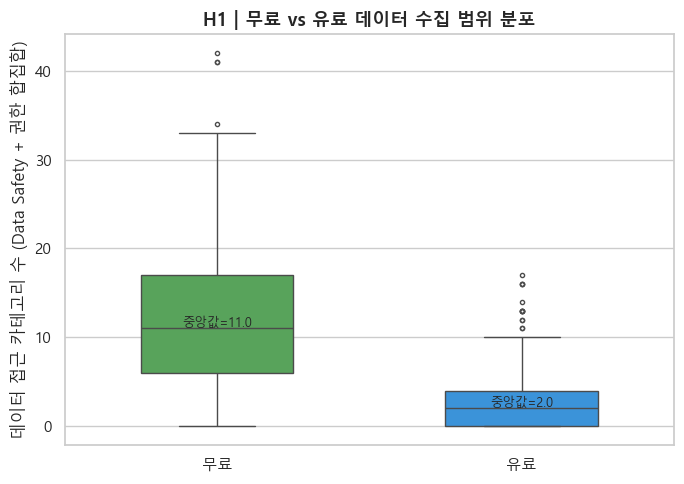

In [72]:
h1_desc = (
    df.groupby("free_label")["unified_data_scope"]
    .agg(["mean", "median", "std", "count"])
    .round(3)
)
display(h1_desc)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=df, x="free_label", y="unified_data_scope",
    order=["무료", "유료"],
    palette={"무료": "#4CAF50", "유료": "#2196F3"},
    width=0.5, fliersize=3, ax=ax,
)
ax.set_title("H1 | 무료 vs 유료 데이터 수집 범위 분포", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("데이터 접근 카테고리 수 (Data Safety + 권한 합집합)")
for i, label in enumerate(["무료", "유료"]):
    med = df[df["free_label"] == label]["unified_data_scope"].median()
    ax.text(i, med + 0.2, f"중앙값={med:.1f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

기술통계 결과, 무료 앱의 평균 수집 카테고리 수는 11.89개로 유료 앱(2.85개)의 약 4.2배에 달하며, 중앙값 기준으로도 무료 앱(11.0개)이 유료 앱(2.0개)보다 5.5배 높게 나타났다. 분포의 중심과 퍼짐 모두에서 무료 앱의 수집 카테고리 수가 유료 앱보다 압도적으로 많음을 확인할 수 있다.

### 3-2. Mann-Whitney U 검정
종속변수(`unified_data_scope`)는 OS 레벨 권한 요청과 Data Safety 신고를 합집합으로
통합한 데이터 수집 카테고리 수로, 유료 앱을 중심으로 Data Safety 미신고 앱이 많아
0에 가까운 값이 지배적이며 분포가 오른쪽으로 심하게 치우쳐 있다.
이처럼 정규성을 가정하기 어려운 카운트 데이터이므로, 비모수 검정인 Mann-Whitney U 검정을 사용한다.

In [73]:
# Shapiro-Wilk 정규성 검정
free_vals = df[df["free_label"] == "무료"]["unified_data_scope"].values
paid_vals = df[df["free_label"] == "유료"]["unified_data_scope"].values

stat_f, p_f = stats.shapiro(free_vals[:5000])
stat_p, p_p = stats.shapiro(paid_vals[:5000])

print(f"무료 앱 - W = {stat_f:.4f}, p = {p_f:.4e}")
print(f"유료 앱 - W = {stat_p:.4f}, p = {p_p:.4e}")

무료 앱 - W = 0.9663, p = 2.8786e-15
유료 앱 - W = 0.8254, p = 3.9074e-22


정규성 가정의 위반은 Shapiro-Wilk 검정을 통해 확인하였다.
검정 결과 무료 앱(W = 0.9663, p = 2.88e-15)과 유료 앱(W = 0.8254, p = 3.91e-22) 모두
엄격하게 설정한 유의수준 0.001에서도 정규성 가정이 기각되었으므로,  비모수 검정인 Mann-Whitney U 검정 사용이 적합하다.

In [74]:
free_collected = df[df["free_label"] == "무료"]["unified_data_scope"]
paid_collected = df[df["free_label"] == "유료"]["unified_data_scope"]

stat, p_val = mannwhitneyu(free_collected, paid_collected, alternative="greater")

print("=== Mann-Whitney U 검정 (가설1: 무료 > 유료) ===")
print(f"U 통계량 : {stat:,.0f}")
print(f"p-value  : {p_val:.4e}")
print(f"결론     : {'유의미한 차이 있음 (p < 0.001)' if p_val < 0.05 else '유의미한 차이 없음'}")

=== Mann-Whitney U 검정 (가설1: 무료 > 유료) ===
U 통계량 : 451,879
p-value  : 1.6732e-129
결론     : 유의미한 차이 있음 (p < 0.001)


검정 결과, U 통계량은 451,879였으며 p-value는 1.6732e-129로 나타났다. 본 분석에서는 대규모 표본(1,562개 앱)을 사용하므로 표본 크기가 클수록 작은 차이도 유의하게 검출될 수 있어 유의수준을 0.001로 엄격하게 설정하였다. p-value가 0.001보다 매우 작으므로, 무료 앱과 유료 앱의 데이터 수집 카테고리 수에는 통계적으로 유의미한 차이가 있다. 이는 두 그룹 간의 차이가 단순한 우연이 아니라 실제로 존재하는 구조적 차이임을 의미한다.

### 3-3. Cliff's δ (효과 크기)

p-value는 차이가 존재하는지만 알려줄 뿐, 그 차이가 얼마나 큰지는 말해주지 않는다.
특히 이번 분석 데이터처럼 표본 수가 1,562개로 크면 실질적으로 의미 없는 아주 작은 차이도
p < 0.001로 나올 수 있다. 따라서 통계적 유의성과 별개로, 무료 앱과 유료 앱의 차이가
현실적으로도 의미 있는 수준인지 확인하기 위해 효과 크기 지표인 Cliff's δ를 함께 사용한다.

In [75]:
def cliffs_delta(a, b):
    a, b = np.array(a), np.array(b)
    dominance = sum(1 if x > y else (-1 if x < y else 0)
                    for x in a for y in b)
    return dominance / (len(a) * len(b))

def interpret_delta(d):
    d = abs(d)
    if d < 0.147: return "negligible (무시 가능)"
    if d < 0.330: return "small (소)"
    if d < 0.474: return "medium (중)"
    return "large (대)"

delta = cliffs_delta(free_collected, paid_collected)

print("=== Cliff's δ 효과 크기 ===")
print(f"Cliff's δ : {delta:.4f}")
print(f"해석      : {interpret_delta(delta)}")

=== Cliff's δ 효과 크기 ===
Cliff's δ : 0.7717
해석      : large (대)


분석 결과 Cliff's δ는 0.7717로 큰 효과(large)에 해당한다. 이는 무료 앱에서 임의로
선택한 앱이 유료 앱에서 임의로 선택한 앱보다 데이터 수집 카테고리 수가 더 많을 확률이
약 88.6%임을 의미하며, 통계적으로 유의할 뿐 아니라 실질적으로도 두 집단의 차이가
뚜렷하게 크다는 것을 확인할 수 있다.

### 3-4. Negative Binomial Regression

Mann-Whitney U 검정만으로는 무료 앱과 유료 앱의 차이가 순수하게 무료 앱이기 때문인지,
아니면 카테고리나 설치 수 같은 다른 교란 요인 때문인지 구분할 수 없다. 이를 통제한 후에도
무료 앱 여부 자체가 수집 항목 수에 유의미한 영향을 미치는지 확인하기 위해
Negative Binomial Regression을 사용한다.

In [76]:
df_nb = df[["unified_data_scope", "free01", "ad_supported01", "offers_iap01", "log_installs", "app_category"]].dropna().copy()
base_cat = df_nb["app_category"].value_counts().idxmax()

formula = (
    "unified_data_scope ~ free01 + ad_supported01 + offers_iap01 + log_installs"
    " + C(app_category, Treatment(reference='{}'))".format(base_cat)
)
nb_model = smf.negativebinomial(formula, data=df_nb).fit(disp=False)

coef_free = nb_model.params["free01"]
pval_free = nb_model.pvalues["free01"]
irr_free  = np.exp(coef_free)

print("=== Negative Binomial Regression (카테고리·설치수·수익화모델 통제) ===")
print(f"free01 계수  : {coef_free:.4f}")
print(f"IRR (exp(β)) : {irr_free:.4f}  → 무료 앱이 유료 앱보다 {irr_free:.2f}배 더 수집")
print(f"p-value      : {pval_free:.4e}")
print(f"결론         : {'유의미 (p < 0.001)' if pval_free < 0.001 else '유의미하지 않음'}")

=== Negative Binomial Regression (카테고리·설치수·수익화모델 통제) ===
free01 계수  : 0.7510
IRR (exp(β)) : 2.1192  → 무료 앱이 유료 앱보다 2.12배 더 수집
p-value      : 1.7599e-34
결론         : 유의미 (p < 0.001)


분석 결과 IRR은 2.12로, 카테고리·설치 수·광고 여부·인앱구매 여부를 통제한 후에도 무료 앱은 유료 앱보다 데이터 수집 카테고리 수가 약 2.12배 더 넓게 나타났으며(p < 0.001), 무료 앱 여부의 효과는 통제 후에도 유의미하게 유지되었다. 이는 무료 앱이 더 많은 데이터를 수집하는 현상이 단순히 특정 카테고리나 인기 앱, 혹은 광고·인앱구매 등 수익화 모델의 차이에 기인한 것이 아니라, 무료라는 수익 구조 자체에서 비롯된 구조적 특성임을 확인할 수 있다.

### 3-5. 가설1 결론

In [77]:
h1_supported = (p_val < 0.05) and (pval_free < 0.05)

display(Markdown(f"""
| 검정 | 결과 | 해석 |
|------|------|------|
| Mann-Whitney U | p = {p_val:.4e} | 무료 앱의 수집 범위가 유의미하게 넓음 |
| Cliff's δ | δ = {delta:.3f} ({interpret_delta(delta)}) | 효과 크기 확인 |
| NB Regression (IRR) | {irr_free:.3f} | 카테고리·설치수·수익화모델 통제 후에도 무료 앱이 {irr_free:.2f}배 더 수집 |

**→ 가설1 {"지지됨" if h1_supported else "기각됨"}**
"""))


| 검정 | 결과 | 해석 |
|------|------|------|
| Mann-Whitney U | p = 1.6732e-129 | 무료 앱의 수집 범위가 유의미하게 넓음 |
| Cliff's δ | δ = 0.772 (large (대)) | 효과 크기 확인 |
| NB Regression (IRR) | 2.119 | 카테고리·설치수·수익화모델 통제 후에도 무료 앱이 2.12배 더 수집 |

**→ 가설1 지지됨**


세 가지 분석 결과를 종합하면, Mann-Whitney U 검정에서 p = 1.67e-129로 무료 앱과 유료 앱의 데이터 수집 범위 차이는 통계적으로 명확하게 유의미하였다. Cliff's δ는 0.7717로 큰 효과에 해당해 그 차이가 실질적으로도 뚜렷하였으며, 카테고리·설치 수·광고 여부·인앱구매 여부를 통제한 Negative Binomial Regression에서도 IRR = 2.12로 무료 앱이 유료 앱보다 약 2.12배 더 넓은 수집 범위를 보이는 것으로 나타났다. 이는 무료 앱의 데이터 수집 범위가 더 넓다는 차이가 단순한 우연이나 교란 요인의 영향이 아니라, 통계적·실질적으로 모두 견고하게 뒷받침되는 결과임을 의미한다. 따라서 가설1 "무료 앱은 유료 앱보다 데이터 수집 범위가 더 넓을 것이다"는 지지된다.

------

# 4. 가설2 : 무료 앱의 데이터 사용은 앱 기능 제공 목적보다 수익화 목적과 함께 나타나는 비율이 높을 것이다.

**가설2 :** 무료 앱이 수집한 데이터의 사용 목적은 앱 기능 제공(App functionality)보다 광고·마케팅, 분석, 개인화 등 수익화 목적과 결합되는 비율이 더 높을 것이다.

앞에서 가설1을 통해 무료 앱이 사용자 데이터를 더 많이 수집한다는 것을 확인하였다. 그렇다면 이렇게 수집된 데이터가 실제로 수익화 목적으로 활용되는지를 확인하기 위해 가설을 설정하였다. 특히 공유 데이터는 앱이 수집한 데이터를 제3자에게 넘기는 행위이므로, 공유 데이터의 목적 구조가 수익화와 연결되어 있는지를 중심으로 검증한다.

앞의 공통 전처리에서 만든 free01과 datasafety_long_df의 목적별 플래그(is_advertising, is_analytics, is_personalization, is_app_functionality, is_monetization_purpose)를 사용한다. 가설2 검증은 수익화 목적 비율 비교, Wilson 신뢰구간 분석 순으로 진행한다.

### 4-1. 분석 설계

분석 단위는 앱 단위가 아니라 Data Safety에 공개된 데이터 항목 단위이다. 하나의 앱이 여러 종류의 데이터를 수집하거나 공유하면 여러 행으로 펼쳐지며, 각 행에는 수집/공유 구분, 데이터 유형, 데이터 카테고리, 목적 리스트, 목적별 더미 변수가 포함된다.

목적 그룹은 다음과 같이 정의한다.

| 목적 그룹 | 포함 목적 |
|---|---|
| 기능 제공 목적 | App functionality |
| 수익화 목적 | Advertising or marketing, Analytics, Personalization |

비율은 기본적으로 "해당 수집 또는 공유 데이터 항목 중 특정 목적이 붙은 항목의 비율"로 계산한다. 목적은 복수 선택될 수 있으므로 각 비율의 합은 100%를 초과할 수 있다.

Analytics와 Personalization이 모두 수익화 목적인 것은 아니나, 행동 분석(Analytics)은 광고 타겟팅 고도화에, 맞춤 추천(Personalization)은 구매·광고 효율 제고에 활용될 수 있어 수익화 목적 그룹에 함께 분류하였다. 다만 이 두 목적이 반드시 수익화와 연결된다고 단정할 수 없으므로, 본 분석의 수익화 목적 비율은 실제보다 다소 과대 추정될 가능성이 있음을 유의해야 한다.

In [78]:
# 가설2에 필요한 통계/표시 함수 준비
H2_MONETIZATION_PURPOSES = MONETIZATION_PURPOSES

H2_SENSITIVE_TYPES = SENSITIVE_DATA_TYPES if "SENSITIVE_DATA_TYPES" in globals() else {
    "Personal info", "Location", "Financial info", "Contacts",
    "Device or other IDs", "App activity", "Messages", "Photos and videos", "Files and docs"
}

def h2_pct(x, digits=1):
    if pd.isna(x):
        return "N/A"
    return f"{x * 100:.{digits}f}%"

def h2_wilson_ci(successes, n, alpha=0.05):
    if n == 0:
        return (np.nan, np.nan)
    return proportion_confint(successes, n, alpha=alpha, method="wilson")

print("가설2 분석 준비 완료")

가설2 분석 준비 완료


### 4-2. 무료 앱 필터링 및 Data Safety 목적 정보 파싱

가설2의 메인 분석 대상은 무료 앱의 공유 데이터(sharedData)이다. 앱이 사용자 데이터를 기기에서 가져가는 것이 수집이라면, 공유는 그 데이터를 광고 네트워크나 분석 플랫폼 같은 제3자에게 실제로 넘기는 행위다. 즉, 수익화가 일어나는 지점에 가장 가깝기 때문에 공유 데이터를 중심으로 분석한다. 각 항목에 붙은 목적별 더미 변수(is_app_functionality, is_advertising, is_analytics, is_personalization, is_monetization_purpose)를 분석에 활용한다.

In [79]:
# 무료 앱의 공유 데이터만 필터링
h2_long_df = datasafety_long_df[
    (datasafety_long_df["is_free"] == 1) &
    (datasafety_long_df["data_flow"] == "shared")
].copy()

free_app_n          = datasafety_long_df[datasafety_long_df["is_free"] == 1]["appId"].nunique()
h2_apps_with_items  = h2_long_df["appId"].nunique() if len(h2_long_df) else 0
h2_apps_excluded    = free_app_n - h2_apps_with_items

print(f"무료 앱 전체 수:                       {free_app_n:,}")
print(f"공유 데이터 항목이 있는 무료 앱 수:    {h2_apps_with_items:,}")
print(f"공유 데이터 항목이 없어 제외된 앱 수:  {h2_apps_excluded:,}")

무료 앱 전체 수:                       1,016
공유 데이터 항목이 있는 무료 앱 수:    692
공유 데이터 항목이 없어 제외된 앱 수:  324


### 4-3. 공유 데이터 목적별 결합 비율 비교(클러스터 부트스트랩 신뢰구간)

공유 데이터 항목에서 각 목적이 얼마나 결합되는지 비율로 확인하고, `App functionality`와 `Monetization` 두 목적의 비율을 앱 단위 클러스터 부트스트랩 95% 신뢰구간과 함께 비교한다. 동일 앱 내 항목들은 서로 독립이 아니므로, 항목 간 상관을 반영하기 위해 앱을 클러스터 단위로 샘플링하는 부트스트랩 방식을 사용하였다.

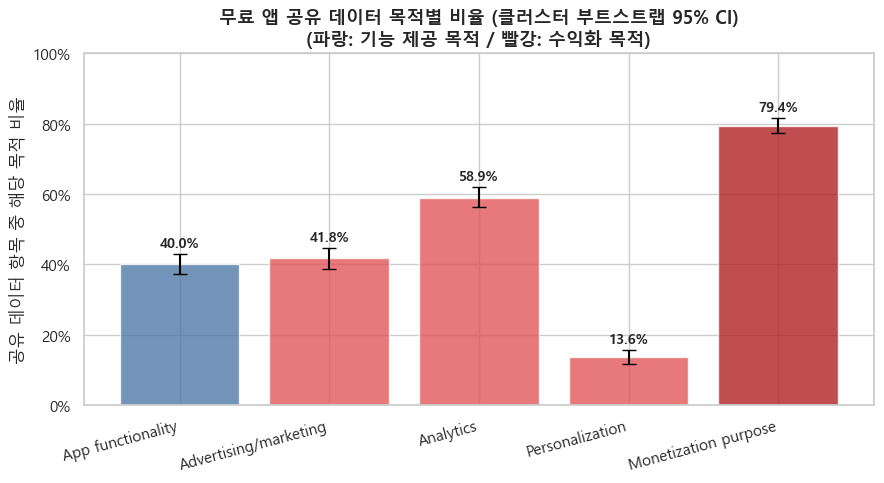

App functionality: 40.0% (95% CI: 37.3% ~ 42.8%)
Advertising/marketing: 41.8% (95% CI: 38.7% ~ 44.6%)
Analytics: 58.9% (95% CI: 56.3% ~ 62.0%)
Personalization: 13.6% (95% CI: 11.7% ~ 15.5%)
Monetization purpose: 79.4% (95% CI: 77.3% ~ 81.5%)


In [80]:
# 목적별 비율 + 클러스터 부트스트랩 CI 계산
h2_purpose_cols = {
    "App functionality":     "is_app_functionality",
    "Advertising/marketing": "is_advertising",
    "Analytics":             "is_analytics",
    "Personalization":       "is_personalization",
    "Monetization purpose":  "is_monetization_purpose",
}

def cluster_bootstrap_ci(df, app_col, target_col, n_boot=500, ci=95, random_state=42):
    rng = np.random.default_rng(random_state)
    app_means = df.groupby(app_col)[target_col].mean().values
    boot_means = [rng.choice(app_means, size=len(app_means), replace=True).mean()
                  for _ in range(n_boot)]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(boot_means), lo, hi

purpose_list = list(h2_purpose_cols.keys())
purpose_col_list = list(h2_purpose_cols.values())

ratios, ci_los, ci_his = [], [], []
for col in purpose_col_list:
    center, lo, hi = cluster_bootstrap_ci(h2_long_df, "appId", col)
    ratios.append(center)
    ci_los.append(lo)
    ci_his.append(hi)

plot_df = pd.DataFrame({
    "목적": purpose_list,
    "비율": ratios,
    "ci_lo": ci_los,
    "ci_hi": ci_his,
    "그룹": ["기능 제공 목적", "수익화 목적", "수익화 목적", "수익화 목적", "수익화 목적(합산)"]
})

palette = {
    "기능 제공 목적": "#4E79A7",
    "수익화 목적": "#E15759",
    "수익화 목적(합산)": "#B22222"
}

fig, ax = plt.subplots(figsize=(9, 5))
for i, row in plot_df.iterrows():
    ax.bar(i, row["비율"], color=palette[row["그룹"]], alpha=0.8)
    ax.errorbar(i, row["비율"],
                yerr=[[row["비율"] - row["ci_lo"]], [row["ci_hi"] - row["비율"]]],
                fmt="none", color="black", capsize=5, linewidth=1.5)
    ax.text(i, row["ci_hi"] + 0.02, f"{row['비율']:.1%}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(purpose_list)))
ax.set_xticklabels(purpose_list, rotation=15, ha="right")
ax.set_title("무료 앱 공유 데이터 목적별 비율 (클러스터 부트스트랩 95% CI)\n(파랑: 기능 제공 목적 / 빨강: 수익화 목적)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("공유 데이터 항목 중 해당 목적 비율")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout(); plt.show()

for _, row in plot_df.iterrows():
    print(f"{row['목적']}: {row['비율']:.1%} (95% CI: {row['ci_lo']:.1%} ~ {row['ci_hi']:.1%})")

무료 앱이 제3자와 공유하는 데이터의 수익화 목적(광고·분석·개인화) 결합 비율은 앱 단위 기준 79.4%로, 앱 기능 제공 목적(40.0%)보다 약 39%p 높게 나타났다. 이는 무료 앱이 공유하는 데이터의 약 79%가 수익화 목적과 함께 명시되어 있음을 확인할 수 있다.

### 4-4. 가설2 결론

| 검정 | 결과 | 해석 |
|------|------|------|
| 목적별 비율 비교 | Monetization 79.4% vs App functionality 40.0% | 공유 데이터의 수익화 목적 결합 비율이 약 39%p 높음 |
| 클러스터 부트스트랩 95% CI | App functionality 37.3%~42.8% / Monetization 77.3%~81.5% | 두 CI가 겹치지 않아 구조적 차이로 확인됨 |

→ 가설2 지지됨

두 가지 분석 결과를 종합하면, 무료 앱이 제3자와 공유하는 데이터 항목 중 수익화 목적(광고·분석·개인화)과 결합된 비율은 앱 단위 기준 79.4%로, 앱 기능 제공 목적(40.0%)보다 약 39%p 높게 나타났다. 두 비율의 95% 클러스터 부트스트랩 신뢰구간이 겹치지 않아 이 차이는 표본 오차에 의한 우연이 아닌 구조적인 차이로 볼 수 있다. 이는 무료 앱이 공유하는 데이터의 대부분이 앱 기능 제공을 위한 것이 아니라, 광고 타겟팅·사용자 행동 분석·개인화 추천 등 수익 창출과 직결된 목적으로 활용되고 있음을 의미한다. 다시 말해, 무료 앱 사용자는 앱을 무료로 사용하는 대신 자신의 데이터를 광고·분석 생태계에 제공하는 구조에 놓여 있다고 볼 수 있다. 따라서 가설2 "무료 앱이 수집한 데이터의 사용 목적은 앱 기능 제공보다 수익화 목적과 결합되는 비율이 더 높을 것이다"는 지지된다.

-------------

# 5. 가설3 : Data Safety 기반 데이터 수집·공유 특성은 고위험 앱 여부를 유의미하게 구분할 수 있을 것이다.

가설3 : Data Safety 기반 데이터 수집·공유 특성은 고위험 앱 여부를 유의미하게 구분할 수 있을 것이다.

앞에서 가설1을 통해 무료 앱이 더 많은 데이터를 수집한다는 것을 확인했고, 가설2를 통해 그 데이터가 수익화 목적과 결합된다는 것을 확인했다. 가설3에서는 고위험 앱을 분석자가 임의로 정의하는 대신, KMeans 군집화로 데이터 구조 자체에서 위험 군집을 먼저 도출한다. 이후 군집 결과를 라벨로 사용하여 Random Forest로 어떤 변수가 고위험 앱을 구분하는지 확인한다.

### 5-1. 고위험 앱 정의(KMeans 군집화)

데이터 수집·공유 특성 변수들로 KMeans 군집화를 수행하여 데이터 구조 자체에서 고위험 군집을 도출한다. 도출된 군집 중 data_risk_score 평균이 높은 군집을 고위험 앱(high_risk=1)으로 정의하여 이후 Random Forest 분류에 사용한다.

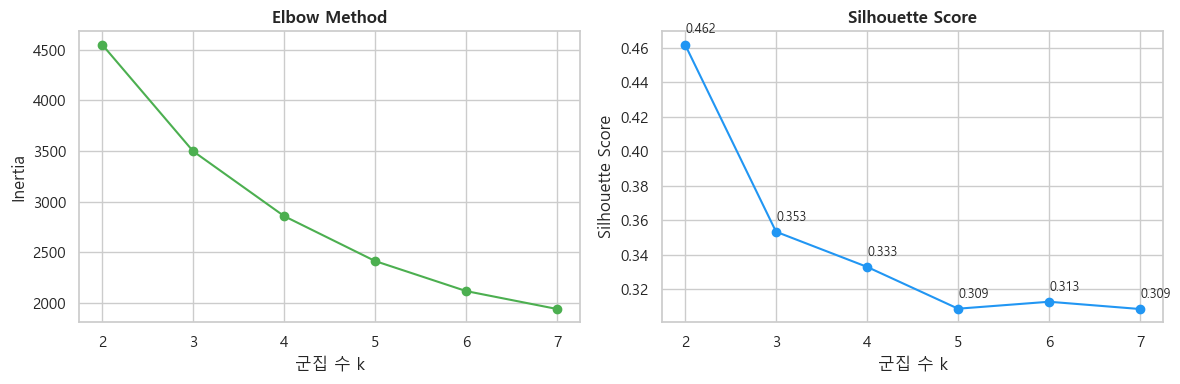

최적 k: 2, Silhouette Score: 0.4620

고위험 군집: Cluster 1 (data_risk_score 평균: 13.71)
고위험 앱 수: 558  /  전체: 1562


,앱 수,unified_data_scope,data_risk_score,free01,ad_supported01,high_risk
cluster,,,,,,
0,1004,4.6000,2.5200,0.5500,0.2900,0.0000
1,558,17.4800,13.7100,0.9800,0.2700,1.0000


In [81]:
CLUSTER_COLS = [
    "unified_data_scope",
    "collected_data_count",
    "shared_data_count",
    "sensitive_data_count",
    "data_risk_score",
    "log_installs",
]
X_scaled = StandardScaler().fit_transform(df[CLUSTER_COLS].fillna(0))

# 최적 k 탐색
inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, marker="o", color="#4CAF50")
axes[0].set_title("Elbow Method", fontsize=12, fontweight="bold")
axes[0].set_xlabel("군집 수 k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="#2196F3")
axes[1].set_title("Silhouette Score", fontsize=12, fontweight="bold")
axes[1].set_xlabel("군집 수 k"); axes[1].set_ylabel("Silhouette Score")
for k, s in zip(k_range, sil_scores):
    axes[1].annotate(f"{s:.3f}", (k, s), textcoords="offset points", xytext=(0, 8), fontsize=9)
plt.tight_layout(); plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"최적 k: {best_k}, Silhouette Score: {max(sil_scores):.4f}")

# 최적 k로 군집화
df["cluster"] = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_scaled)

# data_risk_score 평균이 가장 높은 군집을 고위험으로 정의
cluster_risk = df.groupby("cluster")["data_risk_score"].mean()
high_risk_cluster = cluster_risk.idxmax()
df["high_risk"] = (df["cluster"] == high_risk_cluster).astype(int)

print(f"\n고위험 군집: Cluster {high_risk_cluster} (data_risk_score 평균: {cluster_risk[high_risk_cluster]:.2f})")
print(f"고위험 앱 수: {df['high_risk'].sum()}  /  전체: {len(df)}")

# 군집별 특성 요약
summary = df.groupby("cluster")[["unified_data_scope", "data_risk_score", "free01", "ad_supported01"]].mean().round(2)
summary.insert(0, "앱 수", df["cluster"].value_counts().sort_index())
summary["high_risk"] = df.groupby("cluster")["high_risk"].mean().round(2)
display(summary)

KMeans 군집화(k=2) 결과, data_risk_score 평균이 높은 군집에 속하는 558개 앱을
고위험 앱(high_risk=1)으로 정의하였다. 해당 군집은 unified_data_scope(17.48)와
data_risk_score(13.71)가 저위험 군집 대비 각각 3.8배, 5.4배 높고
무료 앱 비율이 98%로, 데이터 수집·공유 위험도가 구조적으로 높은 앱 그룹임을 확인할 수 있다.

### 5-2. 입력 변수 구성

고위험 앱 여부를 예측하기 위한 입력 변수는 앱의 구조적 데이터 특성으로만 구성한다. `data_risk_score`는 목표 변수 생성에 사용된 변수이므로 입력에서 제외한다. `shared_data_count`와 `sensitive_data_count`는 `data_risk_score`와 구조적으로 높은 상관관계를 가져 모델이 목표 변수를 과도하게 쉽게 학습할 수 있으므로 함께 제외한다.

| 변수 | 설명 |
|------|------|
| `unified_data_scope` | 데이터 수집 카테고리 수 (Data Safety 신고 + OS 권한 합집합) |
| `free01` | 무료 앱 여부 |
| `ad_supported01` | 광고 포함 여부 |
| `offers_iap01` | 인앱구매 여부 |
| `log_installs` | 설치 수 (로그 변환) |
| `app_category` | 앱 카테고리 (원핫인코딩) |

In [82]:
# 5-2. 입력 변수 구성
FEATURE_COLS = [
    "unified_data_scope",
    "free01",
    "ad_supported01",
    "offers_iap01",
    "log_installs",
]
# 카테고리 원핫인코딩
cat_dummies = pd.get_dummies(df["app_category"], prefix="cat", drop_first=True)

# 최종 입력 행렬
X = pd.concat([df[FEATURE_COLS].fillna(0), cat_dummies], axis=1)
y = df["high_risk"]

print(f"\n입력 변수 수: {X.shape[1]}개 (기본 {len(FEATURE_COLS)}개 + 카테고리 더미 {cat_dummies.shape[1]}개)")
print(f"목표 변수 분포:\n{y.value_counts()}")


입력 변수 수: 35개 (기본 5개 + 카테고리 더미 30개)
목표 변수 분포:
high_risk
0    1004
1     558
Name: count, dtype: int64


### 5-3. 고위험 앱 분류를 위한 Random Forest

Data Safety 기반 수집·공유 특성만으로 고위험 앱을 식별할 수 있는지 확인하기 위해 Random Forest 분류 모델을 사용한다. 과적합에 강하고 변수 중요도를 함께 확인할 수 있어 채택하였으며, 고위험 앱(558개)과 저위험 앱(1,004개) 간 클래스 불균형을 보정하기 위해 class_weight='balanced'를 적용하였다.

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.9137,0.9048,0.8482,0.8756,0.9720



5-Fold CV ROC-AUC: 0.9768 ± 0.0066


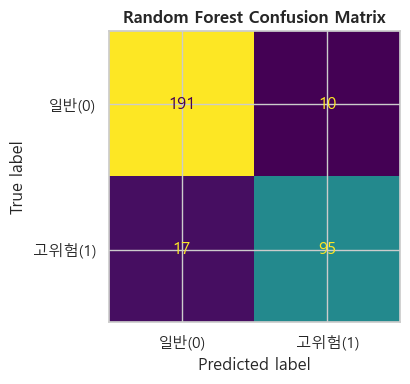

              precision    recall  f1-score   support

          일반       0.92      0.95      0.93       201
         고위험       0.90      0.85      0.88       112

    accuracy                           0.91       313
   macro avg       0.91      0.90      0.90       313
weighted avg       0.91      0.91      0.91       313



In [83]:
# 5-3. Random Forest 분류
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

# 성능 지표
metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1":        f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_prob),
}
display(pd.DataFrame([metrics]).style.format("{:.4f}"))

# 5-fold 교차검증 AUC 과적합 탐지
cv_auc = cross_val_score(rf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                         scoring="roc_auc", n_jobs=-1)
print(f"\n5-Fold CV ROC-AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
                                        display_labels=["일반(0)", "고위험(1)"],
                                        colorbar=False)
ax.set_title("Random Forest Confusion Matrix", fontweight="bold")
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=["일반", "고위험"]))

Random Forest 분류 결과 ROC-AUC 0.972, F1 0.876으로, Data Safety 신고 수집 범위(`unified_data_scope`)와 수익화 구조 변수만으로 고위험 앱을 유의미하게 식별할 수 있음을 확인하였다. 실제 고위험 앱의 84.8%를 탐지(Recall 0.848)하였으며, 5-Fold 교차검증 ROC-AUC 0.977 ± 0.007로 과적합 없이 안정적인 성능이 유지되었다. 전체적으로 수집·공유 구조만으로도 고위험 앱을 유의미하게 구분할 수 있다.

### 5-4. 변수 중요도 분석

Random Forest 모델에서 고위험 앱 분류에 기여한 변수의 중요도를 확인한다. 어떤 수집·공유 특성이 고위험 여부를 결정하는 데 핵심적인 역할을 하는지 파악함으로써 가설3의 해석을 구체화한다.

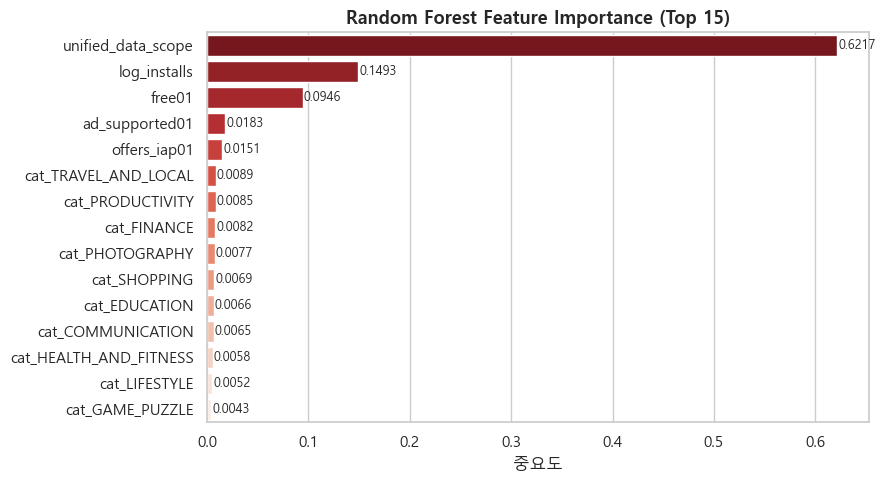

,변수,중요도
0,unified_data_scope,0.6217
1,log_installs,0.1493
2,free01,0.0946
3,ad_supported01,0.0183
4,offers_iap01,0.0151
5,cat_TRAVEL_AND_LOCAL,0.0089
6,cat_PRODUCTIVITY,0.0085
7,cat_FINANCE,0.0082
8,cat_PHOTOGRAPHY,0.0077
9,cat_SHOPPING,0.0069


In [84]:
# 5-4. 변수 중요도 분석
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=top_features.values, y=top_features.index, palette="Reds_r")
ax.set_title("Random Forest Feature Importance (Top 15)", fontsize=13, fontweight="bold")
ax.set_xlabel("중요도")
ax.set_ylabel("")
for i, v in enumerate(top_features.values):
    ax.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

display(top_features.reset_index().rename(columns={"index": "변수", 0: "중요도"})
        .style.format({"중요도": "{:.4f}"}))

통합 수집 범위(`unified_data_scope`, 0.622)가 전체 중요도의 60% 이상을 차지하며 고위험 앱 분류에 압도적으로 기여하였다. 이는 앱이 얼마나 넓은 범위의 데이터에 접근하는지가 고위험 여부를 결정하는 핵심 요인임을 의미한다. 설치 수(0.149)가 그 다음으로 높아 대형 앱일수록 데이터 수집 범위가 넓은 경향을 반영한다. 반면 무료 여부(0.095), 광고 포함(0.018), 인앱구매(0.015)는 상대적으로 낮아, 수익화 모델 자체보다 실제 수집 범위가 위험도를 더 직접적으로 결정함을 보여준다.

### 5-5. 가설3 결론

| 분석 | 결과 | 해석 |
|------|------|------|
| Random Forest | ROC-AUC 0.972, F1 0.876 | Data Safety + 권한 통합 특성으로 고위험 앱 식별 가능 |
| 5-Fold CV AUC | 0.977 ± 0.007 | 안정적인 일반화 성능 확인 |
| Feature Importance | 통합 수집 범위 62.2% | 수집 범위가 위험도의 핵심 결정 요인 |

Data Safety 신고와 OS 권한 데이터를 통합한 수집 특성만으로 고위험 앱을 ROC-AUC 0.972 수준으로 식별할 수 있으며, 5-Fold 교차검증에서도 0.977 ± 0.007로 안정적인 성능이 유지되었다. 특히 변수 중요도 분석에서 통합 수집 범위(`unified_data_scope`)가 전체 중요도의 62.2%를 차지하여, 앱이 얼마나 넓은 범위의 데이터에 접근하는지가 위험도를 결정하는 핵심 요인임을 확인하였다. 이는 사용자가 앱을 설치하기 전 Data Safety 정보와 권한 요청만으로도 해당 앱의 데이터 위험 수준을 유의미하게 판단할 수 있음을 시사한다. 따라서 가설3 "Data Safety 기반 데이터 수집·공유 특성은 고위험 앱 여부를 유의미하게 구분할 수 있을 것이다"는 지지된다.

-------------

# 6. 결론 종합 및 한계점

### 6-1. 가설별 결론 요약

| 가설 | 내용 | 주요 결과 | 결론 |
|------|------|----------|------|
| 가설1 | 무료 앱이 유료 앱보다 데이터 수집 범위가 넓다 | IRR 2.12, Cliff's δ 0.772 | 지지됨 |
| 가설2 | 무료 앱의 공유 데이터는 앱 기능 제공 목적보다 수익화 목적과 더 높은 비율로 결합된다 | Monetization 79.4% vs App functionality 40.0% | 지지됨 |
| 가설3 | Data Safety 및 권한 특성으로 고위험 앱을 식별할 수 있다 | ROC-AUC 0.972, F1 0.876 | 지지됨 |

### 6-2. 종합 인사이트

세 가설의 결과를 종합하면, 무료 앱의 데이터 구조는 하나의 일관된 흐름으로 연결된다. 무료 앱은 유료 앱보다 더 많은 데이터를 수집·공유하고(가설1), 그 데이터의 약 80%가 수익화 목적과 결합되어 제3자에게 넘겨지며(가설2), 이러한 수집·공유 특성만으로도 고위험 앱을 ROC-AUC 0.972 수준으로 식별할 수 있다(가설3). 즉, 무료 앱의 가격 모델은 단순히 결제 비용이 없다는 의미를 넘어, 사용자가 자신의 데이터로 비용을 지불하는 구조임을 데이터로 확인할 수 있다.

이 분석을 통해 다음과 같은 인사이트를 도출할 수 있다.

고위험 앱 사전 탐지: 가설3에서 확인한 것처럼 Data Safety 기반 수집·공유 특성만으로 고위험 앱을 ROC-AUC 0.972 수준으로 식별할 수 있다. 이를 실용화하기 위해 Google Play 앱 페이지에서 Data Safety 정보를 자동으로 읽어 위험도 점수를 표시하는 크롬 익스텐션을 실제로 개발하였다. 이를 통해 앱 설치 전 위험도를 즉시 확인할 수 있으며, '무료'라는 이름 뒤에
숨겨진 데이터 수집 구조를 인지하여 개인정보 과다 수집 앱을 사전에 식별하는 데활용할 수 있다. ([App Risk Scanner 크롬 익스텐션](https://chromewebstore.google.com/detail/app-risk-scanner/hdbgjecbgikgjiidgainklofbeemkhmj?hl=ko))

### 6-3. 한계점

In [85]:
# Data Safety 미기재 앱 현황
df["has_data_safety"] = (df["collected_data_count"] > 0).astype(int)

check = df.groupby("free_label")["has_data_safety"].agg(
    전체=("count"),
    기재=("sum"),
).assign(미기재=lambda x: x["전체"] - x["기재"],
         기재율=lambda x: x["기재"] / x["전체"])

display(check.style.format({"기재율": "{:.2%}"}))

,전체,기재,미기재,기재율
free_label,,,,
무료,1097,914,183,83.32%
유료,465,152,313,32.69%


분석에서 활용한 Google Play의 'Data Safety' 정보는 개발자의 자기 신고 체계에 의존한다. 수집 범위는 OS 레벨 권한 요청(`permissionsRaw`)을 합집합으로 보완하여 과소 측정 문제를 일부 해결하였으나, 공유 범위(`sharedData`)는 여전히 자기신고에만 의존하므로 공유 항목 0건이 실제 미공유를 의미하는지 신고 누락인지 판별할 수 없다. 따라서 분석에서 도출된 데이터 공유 규모는 실제 위험 수준의 하한선으로 해석하는 것이 타당하다.

Analytics와 Personalization이 모두 수익화 목적인 것은 아니나, 행동 분석(Analytics)은 광고 타겟팅 고도화에, 맞춤 추천(Personalization)은 구매·광고 효율 제고에 활용될 수 있어 수익화 목적 그룹에 함께 분류하였다. 다만 이 두 목적이 반드시 수익화와 연결된다고 단정할 수 없으므로, 본 분석의 수익화 목적 비율은 실제보다 다소 과대 추정될 가능성이 있음을 유의해야 한다.

### 6-4. 향후 계획

분석에서는 수집 범위의 과소 측정 문제를 OS 레벨 권한 데이터(permissionsRaw)로 보완하였으나, 공유 범위(sharedData)는 여전히 개발자 자기신고에 의존한다. 네트워크 트래픽 분석이나 동적 앱 실행 환경(샌드박스)을 활용하면 실제 제3자 전송 여부를 검증할 수 있을 것이다.